# Factor Zoo Research

## Objective

Evaluate multiple cross-sectional factors on the NIFTY 500 universe from 2015–2025.

Factors:

- Momentum63
- Momentum126
- Relative Strength
- Trend Strength
- Volatility
- Breakout Strength
- Volume Trend

Evaluation:

1. Information Coefficient (IC)
2. Top vs Bottom Portfolio Spread
3. Factor Ranking

Only factors demonstrating predictive power will be included in the final alpha model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

close = pd.read_pickle(
    "../data/nifty500_close_clean.pkl"
)

open_ = pd.read_pickle(
    "../data/open.pkl"
)

high = pd.read_pickle(
    "../data/high.pkl"
)

low = pd.read_pickle(
    "../data/low.pkl"
)

volume = pd.read_pickle(
    "../data/volume.pkl"
)

returns = close.pct_change()

print("Close :", close.shape)
print("Open  :", open_.shape)
print("High  :", high.shape)
print("Low   :", low.shape)
print("Volume:", volume.shape)

print(
    "\nDate Range:",
    close.index.min().date(),
    "to",
    close.index.max().date()
)

Close : (2716, 332)
Open  : (2716, 500)
High  : (2716, 500)
Low   : (2716, 500)
Volume: (2716, 500)

Date Range: 2015-01-01 to 2025-12-31


In [2]:
# =========================
# MOMENTUM
# =========================

mom63 = close.pct_change(63).shift(1)

mom126 = close.pct_change(126).shift(1)

# =========================
# RELATIVE STRENGTH
# =========================

universe_return = (
    close
    .pct_change(63)
    .median(axis=1)
    .shift(1)
)

relative_strength = (
    close.pct_change(63)
    .shift(1)
    .sub(universe_return, axis=0)
)

# =========================
# TREND STRENGTH
# =========================

ema100 = (
    close
    .ewm(span=100, adjust=False)
    .mean()
    .shift(1)
)

trend_strength = (
    close.shift(1) / ema100
) - 1

# =========================
# VOLATILITY
# =========================

vol20 = (
    returns
    .rolling(20)
    .std()
    .shift(1)
)

# =========================
# BREAKOUT
# =========================

breakout = (
    close.shift(1)
    /
    close.shift(1).rolling(126).max()
)

# =========================
# VOLUME TREND
# =========================

volume_trend = (
    volume.shift(1)
    /
    volume.shift(1).rolling(60).mean()
)

# =========================
# FUTURE RETURNS
# =========================

future_63 = (
    close
    .pct_change(63)
    .shift(-63)
)

In [3]:
def mean_ic(factor, future_returns):

    ics = []

    for date in factor.index:

        x = factor.loc[date]

        y = future_returns.loc[date]

        valid = (
            pd.concat([x, y], axis=1)
            .dropna()
        )

        if len(valid) < 30:
            continue

        ic = valid.iloc[:,0].corr(
            valid.iloc[:,1],
            method="spearman"
        )

        ics.append(ic)

    return np.nanmean(ics)

In [4]:
factor_results = pd.DataFrame({

    "Factor":[
        "Momentum63",
        "Momentum126",
        "RelativeStrength",
        "TrendStrength",
        "Volatility",
        "Breakout",
        "VolumeTrend"
    ],

    "Mean IC":[

        mean_ic(mom63, future_63),

        mean_ic(mom126, future_63),

        mean_ic(relative_strength, future_63),

        mean_ic(trend_strength, future_63),

        mean_ic(-vol20, future_63),

        mean_ic(breakout, future_63),

        mean_ic(volume_trend, future_63)

    ]

})

factor_results.sort_values(
    "Mean IC",
    ascending=False
)

c:\Users\SaiAshwin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\nanops.py:1673: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


,Factor,Mean IC
1,Momentum126,0.042747
3,TrendStrength,0.035823
0,Momentum63,0.025828
2,RelativeStrength,0.025828
5,Breakout,0.023862
4,Volatility,-0.001896
6,VolumeTrend,-0.004936


In [5]:
def top_bottom_spread(factor, future_returns, n=10):

    top_returns = []
    bottom_returns = []

    for date in factor.index:

        scores = factor.loc[date]
        future = future_returns.loc[date]

        valid = pd.DataFrame({
            "score": scores,
            "future": future
        }).dropna()

        if len(valid) < 2 * n:
            continue

        top = (
            valid
            .nlargest(n, "score")["future"]
            .mean()
        )

        bottom = (
            valid
            .nsmallest(n, "score")["future"]
            .mean()
        )

        top_returns.append(top)
        bottom_returns.append(bottom)

    return {
        "Top": np.mean(top_returns),
        "Bottom": np.mean(bottom_returns),
        "Spread": np.mean(top_returns) - np.mean(bottom_returns)
    }

In [6]:
results = pd.DataFrame({
    "Momentum126": top_bottom_spread(mom126, future_63),
    "TrendStrength": top_bottom_spread(trend_strength, future_63),
    "Momentum63": top_bottom_spread(mom63, future_63),
    "Breakout": top_bottom_spread(breakout, future_63)
}).T

results

,Top,Bottom,Spread
Momentum126,0.119828,0.075526,0.044302
TrendStrength,0.101136,0.080578,0.020558
Momentum63,0.100562,0.093482,0.007080
Breakout,0.062442,0.104749,-0.042306


In [7]:
mom126_rank = mom126.rank(axis=1, pct=True)

trend_rank = trend_strength.rank(axis=1, pct=True)

alpha_score = (
    0.7 * mom126_rank +
    0.3 * trend_rank
)

In [8]:
combined_ic = mean_ic(
    alpha_score,
    future_63
)

combined_spread = top_bottom_spread(
    alpha_score,
    future_63
)

print("IC:", combined_ic)
print(combined_spread)

IC: 0.041557195690696075
{'Top': np.float64(0.11268497343379404), 'Bottom': np.float64(0.07375014214054676), 'Spread': np.float64(0.03893483129324728)}


In [9]:
summary = pd.DataFrame({
    "IC":[
        0.0427,
        0.0358,
        0.0258,
        0.0239,
        0.0416
    ],
    "Spread":[
        0.0443,
        0.0206,
        0.0071,
        -0.0423,
        0.0389
    ]
},
index=[
    "Momentum126",
    "TrendStrength",
    "Momentum63",
    "Breakout",
    "Combined"
])

summary.sort_values(
    "Spread",
    ascending=False
)

,IC,Spread
Momentum126,0.0427,0.0443
Combined,0.0416,0.0389
TrendStrength,0.0358,0.0206
Momentum63,0.0258,0.0071
Breakout,0.0239,-0.0423


In [10]:
portfolio_sizes = [5, 10, 20, 30, 50]

results = []

for n in portfolio_sizes:

    spread_stats = top_bottom_spread(
        mom126,
        future_63,
        n=n
    )

    results.append({
        "Top N": n,
        "Top Return": spread_stats["Top"],
        "Bottom Return": spread_stats["Bottom"],
        "Spread": spread_stats["Spread"]
    })

portfolio_results = pd.DataFrame(results)

portfolio_results

,Top N,Top Return,Bottom Return,Spread
0,5,0.120887,0.098244,0.022643
1,10,0.119828,0.075526,0.044302
2,20,0.109338,0.065097,0.044241
3,30,0.100702,0.061254,0.039448
4,50,0.090423,0.059131,0.031292


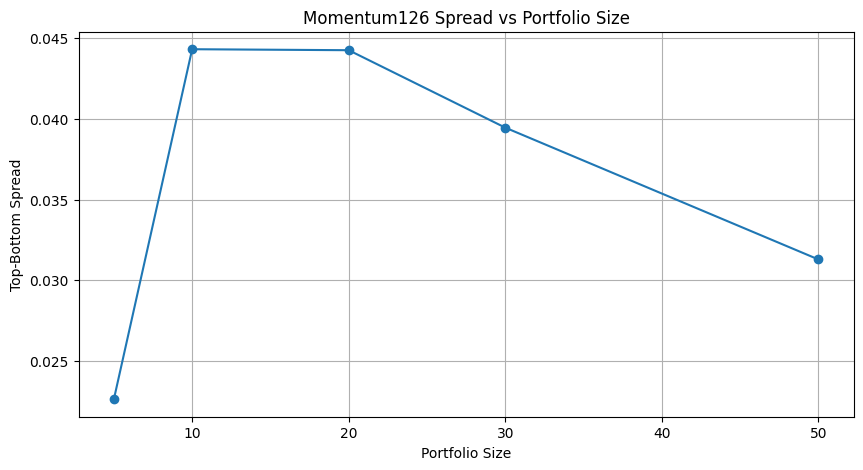

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(
    portfolio_results["Top N"],
    portfolio_results["Spread"],
    marker="o"
)

plt.title(
    "Momentum126 Spread vs Portfolio Size"
)

plt.xlabel(
    "Portfolio Size"
)

plt.ylabel(
    "Top-Bottom Spread"
)

plt.grid(True)

plt.savefig(
    "../results/plots/02_portfolio_size_analysis.png",
    bbox_inches="tight"
)

plt.show()

In [14]:
factor_results.to_csv(
    "../results/tables/02_ic_results.csv"
)

portfolio_results.to_csv(
    "../results/tables/02_top_bottom_spread.csv"
)

factor_results.to_csv(
    "../results/tables/02_ic_results.csv"
)



## Momentum126 Portfolio Size Analysis

Momentum126 exhibits the strongest predictive power when applied to concentrated portfolios.

Results:

| Portfolio Size | Spread |
|---------------|---------|
| 5 | 2.26% |
| 10 | 4.43% |
| 20 | 4.42% |
| 30 | 3.94% |
| 50 | 3.13% |

Key Findings:

- Top 10 and Top 20 portfolios produced the highest spreads.
- Increasing diversification beyond 20 stocks diluted the alpha signal.
- Extremely concentrated portfolios (Top 5) showed lower effectiveness.
- Future portfolio construction will focus on Top 10–20 ranked stocks.